Parameters for the double pendulum saved in random_double_pendulum.pkl


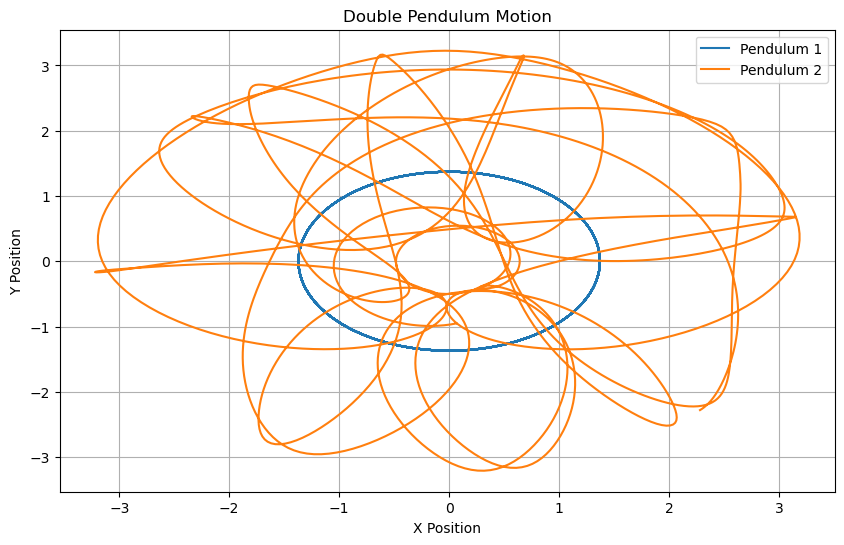

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pickle

# Define the parameters
params = {
    "I": np.random.rand(),                  # Moment of inertia of buoy
    "M": np.random.rand(),                  # Mass of fixed part of WITT device
    "m": np.random.rand(),                  # Mass of WITT pendulum
    "a": np.random.rand() + 1.0,            # Length of first pendulum (ensuring it's not zero)
    "b": np.random.rand() + 1.0,            # Length of second pendulum (ensuring it's not zero)
    "A": np.random.rand(),                  # Amplitude of wave gradient
    "omega": np.random.rand(),              # Frequency of waves
    "k": np.random.rand(),                  # Buoy stability factor
    "U_theta": lambda theta: np.random.rand() * theta,  # Pendulum constraint on buoy
    "N": np.random.rand(),                  # Buoy damping coefficient
    "nu_theta": lambda theta: np.random.rand() * theta,  # Pendulum damping coefficient
    "lambda": np.random.rand()              # WITT energy extraction coefficient
}

# Remove functions from the parameters for pickling
params_to_pickle = params.copy()
params_to_pickle.pop("U_theta")
params_to_pickle.pop("nu_theta")

# Save the parameters to a pickle file
filename = 'random_double_pendulum.pkl'
with open(filename, 'wb') as file:
    pickle.dump(params_to_pickle, file)

print(f"Parameters for the double pendulum saved in {filename}")

# Load the parameters
with open(filename, 'rb') as file:
    loaded_params = pickle.load(file)

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = params["U_theta"]
loaded_params["nu_theta"] = params["nu_theta"]

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Initial conditions
alpha0 = np.pi / 4
theta0 = np.pi / 4
alpha_dot0 = 0.0
theta_dot0 = 0.0
initial_conditions = [alpha0, theta0, alpha_dot0, theta_dot0]

# Time array
t_max = 20  # Increase time to see more dynamics
dt = 0.01
t = np.arange(0, t_max, dt)

# Equations of motion for the double pendulum
def equations_of_motion(t, y, params):
    a, b = params['a'], params['b']
    m, M = params['m'], params['M']

    alpha, theta, alpha_dot, theta_dot = y

    delta = theta - alpha

    den1 = (M + m) * a - m * b * np.cos(delta) ** 2
    den2 = (M + m) * b - m * a * np.cos(delta) ** 2

    alpha_ddot = ((m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   m * g * np.sin(theta) * np.cos(delta) +
                   m * b * theta_dot ** 2 * np.sin(delta) -
                   (M + m) * g * np.sin(alpha)) / den1)

    theta_ddot = ((-m * a * alpha_dot ** 2 * np.sin(delta) +
                   (M + m) * g * np.sin(alpha) * np.cos(delta) -
                   m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   (M + m) * g * np.sin(theta)) / den2)

    return [alpha_dot, theta_dot, alpha_ddot, theta_ddot]

# Solve the ODE
sol = solve_ivp(equations_of_motion, [0, t_max], initial_conditions, t_eval=t, args=(loaded_params,))

alpha = sol.y[0]
theta = sol.y[1]

# Compute the positions of the pendulum masses
x1 = loaded_params['a'] * np.sin(alpha)
y1 = -loaded_params['a'] * np.cos(alpha)
x2 = x1 + loaded_params['b'] * np.sin(theta)
y2 = y1 - loaded_params['b'] * np.cos(theta)

# Plot the motion of the double pendulum
plt.figure(figsize=(10, 6))
plt.plot(x1, y1, label='Pendulum 1')
plt.plot(x2, y2, label='Pendulum 2')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Double Pendulum Motion')
plt.legend()
plt.grid()
plt.show()


Parameters for the double pendulum saved in random_double_pendulum.pkl


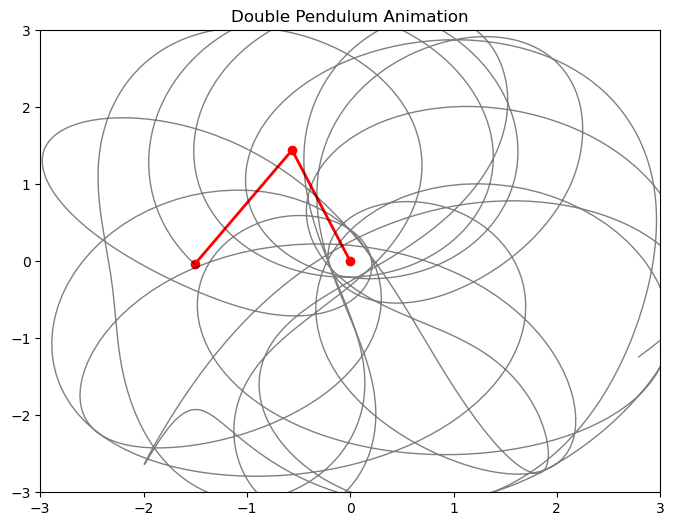

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.integrate import solve_ivp
import pickle

# Define the parameters
params = {
    "I": np.random.rand(),                  # Moment of inertia of buoy
    "M": np.random.rand(),                  # Mass of fixed part of WITT device
    "m": np.random.rand(),                  # Mass of WITT pendulum
    "a": np.random.rand() + 1.0,            # Length of first pendulum (ensuring it's not zero)
    "b": np.random.rand() + 1.0,            # Length of second pendulum (ensuring it's not zero)
    "A": np.random.rand(),                  # Amplitude of wave gradient
    "omega": np.random.rand(),              # Frequency of waves
    "k": np.random.rand(),                  # Buoy stability factor
    "U_theta": lambda theta: np.random.rand() * theta,  # Pendulum constraint on buoy
    "N": np.random.rand(),                  # Buoy damping coefficient
    "nu_theta": lambda theta: np.random.rand() * theta,  # Pendulum damping coefficient
    "lambda": np.random.rand()              # WITT energy extraction coefficient
}

# Remove functions from the parameters for pickling
params_to_pickle = params.copy()
params_to_pickle.pop("U_theta")
params_to_pickle.pop("nu_theta")

# Save the parameters to a pickle file
filename = 'random_double_pendulum.pkl'
with open(filename, 'wb') as file:
    pickle.dump(params_to_pickle, file)

print(f"Parameters for the double pendulum saved in {filename}")

# Load the parameters
with open(filename, 'rb') as file:
    loaded_params = pickle.load(file)

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = params["U_theta"]
loaded_params["nu_theta"] = params["nu_theta"]

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Initial conditions
alpha0 = np.pi / 2   # Starting the inner pendulum at the top
theta0 = np.pi / 4   # Initial angle for the second pendulum
alpha_dot0 = 0.0
theta_dot0 = 2.0     # Initial angular velocity for the second pendulum to create the desired motion
initial_conditions = [alpha0, theta0, alpha_dot0, theta_dot0]

# Time array
t_max = 20  # Increase time to see more dynamics
dt = 0.01
t = np.arange(0, t_max, dt)

# Equations of motion for the double pendulum
def equations_of_motion(t, y, params):
    a, b = params['a'], params['b']
    m, M = params['m'], params['M']

    alpha, theta, alpha_dot, theta_dot = y

    delta = theta - alpha

    den1 = (M + m) * a - m * b * np.cos(delta) ** 2
    den2 = (M + m) * b - m * a * np.cos(delta) ** 2

    alpha_ddot = ((m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   m * g * np.sin(theta) * np.cos(delta) +
                   m * b * theta_dot ** 2 * np.sin(delta) -
                   (M + m) * g * np.sin(alpha)) / den1)

    theta_ddot = ((-m * a * alpha_dot ** 2 * np.sin(delta) +
                   (M + m) * g * np.sin(alpha) * np.cos(delta) -
                   m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   (M + m) * g * np.sin(theta)) / den2)

    return [alpha_dot, theta_dot, alpha_ddot, theta_ddot]

# Solve the ODE
sol = solve_ivp(equations_of_motion, [0, t_max], initial_conditions, t_eval=t, args=(loaded_params,))

alpha = sol.y[0]
theta = sol.y[1]

# Compute the positions of the pendulum masses
x1 = loaded_params['a'] * np.sin(alpha)
y1 = -loaded_params['a'] * np.cos(alpha)
x2 = x1 + loaded_params['b'] * np.sin(theta)
y2 = y1 - loaded_params['b'] * np.cos(theta)

# Animation function
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame]]
    thisy = [0, y1[frame], y2[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x2[frame], y2[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('double_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Double Pendulum Animation')
plt.show()


In [4]:
for key, value in loaded_params.items():
    print(f"{key}: {value}")

I: 0.5922618006300971
M: 0.5797636326730176
m: 0.20385430965656381
a: 1.566342593105271
b: 1.664680434111303
A: 0.2935043823457788
omega: 0.15674361040842755
k: 0.7339895118075067
N: 0.5341411352448037
lambda: 0.6440926485208677
U_theta: <function <lambda> at 0x000001DFF03A2840>
nu_theta: <function <lambda> at 0x000001DFF17E3740>


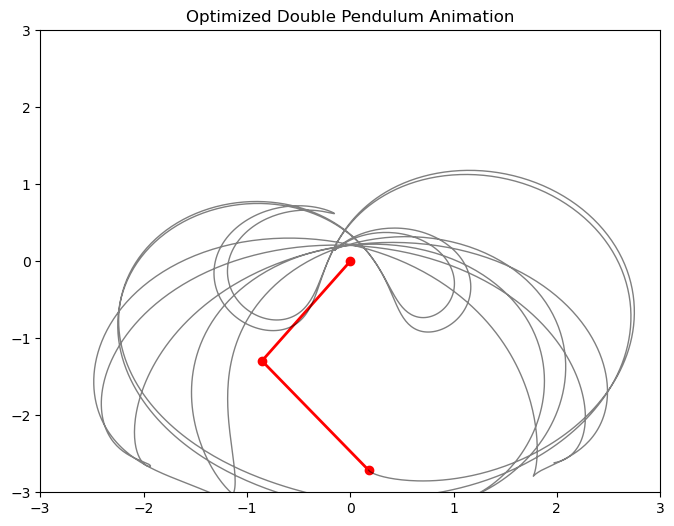

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.signal import find_peaks
import pickle

# Load the parameters from the pickle file
with open('random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Initial conditions
initial_conditions = [np.pi / 4, np.pi / 6, 0.0, 0.0]

# Time array
t_max = 20
dt = 0.01
t = np.arange(0, t_max, dt)

# Desired frequency of oscillation
desired_frequency = 0.5  # Hz

# Define the equations of motion for the double pendulum
def equations_of_motion(t, y, params):
    a, b = params['a'], params['b']
    m, M = params['m'], params['M']

    alpha, theta, alpha_dot, theta_dot = y

    delta = theta - alpha

    den1 = (M + m) * a - m * b * np.cos(delta) ** 2
    den2 = (M + m) * b - m * a * np.cos(delta) ** 2

    alpha_ddot = ((m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   m * g * np.sin(theta) * np.cos(delta) +
                   m * b * theta_dot ** 2 * np.sin(delta) -
                   (M + m) * g * np.sin(alpha)) / den1)

    theta_ddot = ((-m * a * alpha_dot ** 2 * np.sin(delta) +
                   (M + m) * g * np.sin(alpha) * np.cos(delta) -
                   m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   (M + m) * g * np.sin(theta)) / den2)

    return [alpha_dot, theta_dot, alpha_ddot, theta_ddot]

# Define the simulation function
def simulate(params, initial_conditions, t):
    sol = solve_ivp(equations_of_motion, [t[0], t[-1]], initial_conditions, t_eval=t, args=(params,))
    return sol.y

# Define the objective function for least squares optimization
def objective_function(x, initial_conditions, t, desired_frequency):
    params = loaded_params.copy()
    params['I'] = x[0]
    params['a'] = x[1]
    params['b'] = x[2]
    params['nu_theta'] = lambda theta: x[3] * theta
    params['N'] = x[4]
    
    y = simulate(params, initial_conditions, t)
    
    # Calculate the frequency of the oscillations
    y1 = y[0]  # Let's take the first pendulum's angle for frequency calculation
    peaks, _ = find_peaks(y1)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
    
    return actual_frequency - desired_frequency

# Initial guess for the parameters
initial_guess = [loaded_params['I'], loaded_params['a'], loaded_params['b'], 0.1, loaded_params['N']]

# Perform the optimization
result = least_squares(objective_function, initial_guess, args=(initial_conditions, t, desired_frequency))

# Update the parameters with the optimized values
loaded_params['I'] = result.x[0]
loaded_params['a'] = result.x[1]
loaded_params['b'] = result.x[2]
loaded_params['nu_theta'] = lambda theta: result.x[3] * theta
loaded_params['N'] = result.x[4]

# Simulate with the optimized parameters
y_optimized = simulate(loaded_params, initial_conditions, t)

# Plot the optimized motion
x1 = loaded_params['a'] * np.sin(y_optimized[0])
y1 = -loaded_params['a'] * np.cos(y_optimized[0])
x2 = x1 + loaded_params['b'] * np.sin(y_optimized[1])
y2 = y1 - loaded_params['b'] * np.cos(y_optimized[1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame]]
    thisy = [0, y1[frame], y2[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x2[frame], y2[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_double_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Double Pendulum Animation')
plt.show()


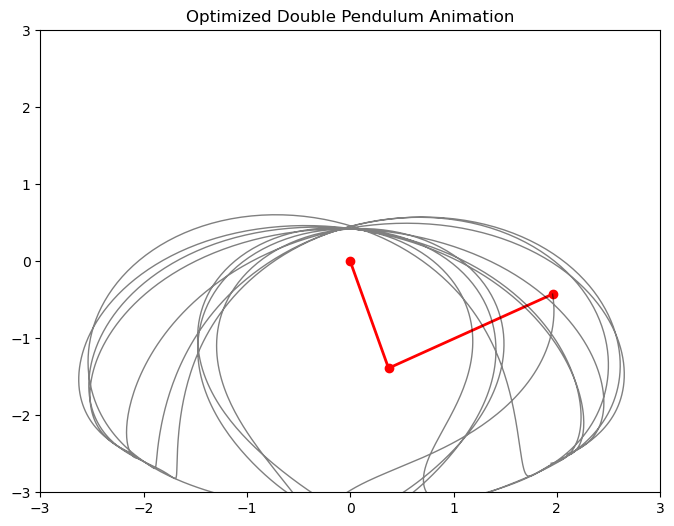

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.signal import find_peaks
import pickle

# Load the parameters from the pickle file
with open('random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Initial conditions
initial_conditions = [np.pi / 4, np.pi / 6, 0.0, 0.0]

# Time array
t_max = 20
dt = 0.01
t = np.arange(0, t_max, dt)

# Desired frequency of oscillation
desired_frequency = 3.0  # Target frequency, 3 times higher than the background wave

# Define the equations of motion for the double pendulum
def equations_of_motion(t, y, params):
    a, b = params['a'], params['b']
    m, M = params['m'], params['M']

    alpha, theta, alpha_dot, theta_dot = y

    delta = theta - alpha

    den1 = (M + m) * a - m * b * np.cos(delta) ** 2
    den2 = (M + m) * b - m * a * np.cos(delta) ** 2

    alpha_ddot = ((m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   m * g * np.sin(theta) * np.cos(delta) +
                   m * b * theta_dot ** 2 * np.sin(delta) -
                   (M + m) * g * np.sin(alpha)) / den1)

    theta_ddot = ((-m * a * alpha_dot ** 2 * np.sin(delta) +
                   (M + m) * g * np.sin(alpha) * np.cos(delta) -
                   m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   (M + m) * g * np.sin(theta)) / den2)

    return [alpha_dot, theta_dot, alpha_ddot, theta_ddot]

# Define the simulation function
def simulate(params, initial_conditions, t):
    sol = solve_ivp(equations_of_motion, [t[0], t[-1]], initial_conditions, t_eval=t, args=(params,))
    return sol.y

# Define the objective function for least squares optimization
def objective_function(x, initial_conditions, t, desired_frequency):
    params = loaded_params.copy()
    params['I'] = x[0]
    params['a'] = x[1]
    params['b'] = x[2]
    params['nu_theta'] = lambda theta: x[3] * theta
    params['N'] = x[4]
    
    y = simulate(params, initial_conditions, t)
    
    # Calculate the frequency of the oscillations
    y1 = y[0]  # Let's take the first pendulum's angle for frequency calculation
    peaks, _ = find_peaks(y1)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
    
    # Incorporate low-impact internal dynamics in the optimization
    energy_loss = np.sum(np.abs(y1))  # Example metric for energy loss

    # Return combined objective (frequency difference and energy loss)
    return np.array([actual_frequency - desired_frequency, energy_loss])

# Initial guess for the parameters
initial_guess = [loaded_params['I'], loaded_params['a'], loaded_params['b'], 0.1, loaded_params['N']]

# Perform the optimization
result = least_squares(objective_function, initial_guess, args=(initial_conditions, t, desired_frequency))

# Update the parameters with the optimized values
loaded_params['I'] = result.x[0]
loaded_params['a'] = result.x[1]
loaded_params['b'] = result.x[2]
loaded_params['nu_theta'] = lambda theta: result.x[3] * theta
loaded_params['N'] = result.x[4]

# Simulate with the optimized parameters
y_optimized = simulate(loaded_params, initial_conditions, t)

# Plot the optimized motion
x1 = loaded_params['a'] * np.sin(y_optimized[0])
y1 = -loaded_params['a'] * np.cos(y_optimized[0])
x2 = x1 + loaded_params['b'] * np.sin(y_optimized[1])
y2 = y1 - loaded_params['b'] * np.cos(y_optimized[1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame]]
    thisy = [0, y1[frame], y2[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x2[frame], y2[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_double_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Double Pendulum Animation')
plt.show()


In [4]:
print("Optimized parameters:")
print("I (moment of inertia):", result.x[0])
print("a (length of first pendulum):", result.x[1])
print("b (length of second pendulum):", result.x[2])
print("nu_theta coefficient:", result.x[3])
print("N (buoy damping coefficient):", result.x[4])

Optimized parameters:
I (moment of inertia): 0.2623135612786178
a (length of first pendulum): 1.437043184185134
b (length of second pendulum): 1.855813558038778
nu_theta coefficient: 0.1
N (buoy damping coefficient): 0.2830561228714604


Optimized parameters:
I (moment of inertia): 0.2623135612786178
a (length of first pendulum): 1.5237658879751932
b (length of second pendulum): 1.77857230359396
nu_theta coefficient: 0.1
N (buoy damping coefficient): 0.2830561228714604


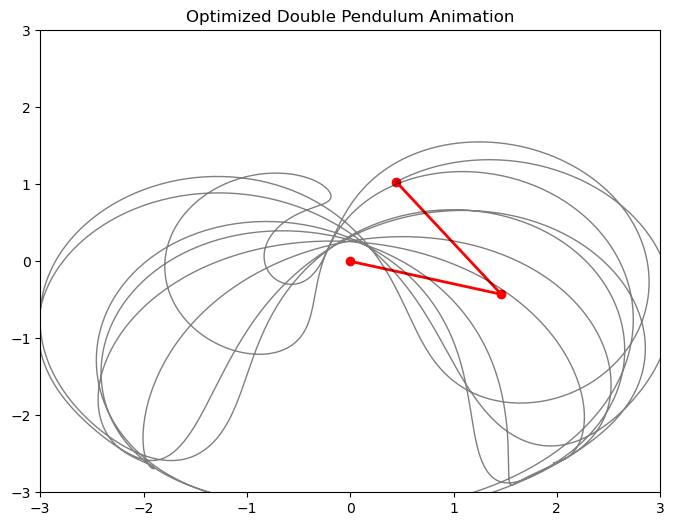

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.signal import find_peaks
import pickle

# Load the parameters from the pickle file
with open('random_double_pendulum.pkl', 'rb') as file:
    loaded_params = pickle.load(file)

# Add the functions back to the loaded parameters
loaded_params["U_theta"] = lambda theta: 0.1 * theta
loaded_params["nu_theta"] = lambda theta: 0.1 * theta

# Simulation parameters
g = 9.81  # acceleration due to gravity

# Initial conditions
initial_conditions = [np.pi / 4, np.pi / 6, 0.0, 0.0]

# Time array
t_max = 20
dt = 0.01
t = np.arange(0, t_max, dt)

# Desired frequency of oscillation
desired_frequency = 3.0  # Target frequency, 3 times higher than the background wave

# Define the equations of motion for the double pendulum
def equations_of_motion(t, y, params):
    a, b = params['a'], params['b']
    m, M = params['m'], params['M']

    alpha, theta, alpha_dot, theta_dot = y

    delta = theta - alpha

    den1 = (M + m) * a - m * b * np.cos(delta) ** 2
    den2 = (M + m) * b - m * a * np.cos(delta) ** 2

    alpha_ddot = ((m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   m * g * np.sin(theta) * np.cos(delta) +
                   m * b * theta_dot ** 2 * np.sin(delta) -
                   (M + m) * g * np.sin(alpha)) / den1)

    theta_ddot = ((-m * a * alpha_dot ** 2 * np.sin(delta) +
                   (M + m) * g * np.sin(alpha) * np.cos(delta) -
                   m * b * theta_dot ** 2 * np.sin(delta) * np.cos(delta) +
                   (M + m) * g * np.sin(theta)) / den2)

    return [alpha_dot, theta_dot, alpha_ddot, theta_ddot]

# Define the simulation function
def simulate(params, initial_conditions, t):
    sol = solve_ivp(equations_of_motion, [t[0], t[-1]], initial_conditions, t_eval=t, args=(params,))
    return sol.y

# Define the objective function for least squares optimization
def objective_function(x, initial_conditions, t, desired_frequency):
    params = loaded_params.copy()
    params['I'] = x[0]
    params['a'] = x[1]
    params['b'] = x[2]
    params['nu_theta'] = lambda theta: x[3] * theta
    params['N'] = x[4]
    
    y = simulate(params, initial_conditions, t)
    
    # Calculate the frequency of the oscillations
    y1 = y[0]  # Let's take the first pendulum's angle for frequency calculation
    peaks, _ = find_peaks(y1)
    peak_times = t[peaks]
    actual_frequency = 1 / np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
    
    # Calculate kinetic and potential energy over time
    alpha, theta, alpha_dot, theta_dot = y
    a, b = params['a'], params['b']
    m, M = params['m'], params['M']
    
    # Positions
    y1 = -a * np.cos(alpha)
    y2 = y1 - b * np.cos(theta)
    
    # Velocities
    v1 = a * alpha_dot
    v2 = np.sqrt((a * alpha_dot * np.cos(theta) + b * theta_dot) ** 2 + (a * alpha_dot * np.sin(theta)) ** 2)
    
    # Kinetic energy
    T1 = 0.5 * m * v1 ** 2
    T2 = 0.5 * M * v2 ** 2
    T = T1 + T2
    
    # Potential energy
    V1 = m * g * y1
    V2 = M * g * y2
    V = V1 + V2
    
    # Total energy
    E = T + V
    
    # Calculate energy loss as the decrease in total energy over time
    energy_loss = np.max(E) - np.min(E)

    # Return combined objective (frequency difference and energy loss)
    return np.array([actual_frequency - desired_frequency, energy_loss]) #absolute value
# Initial guess for the parameters
initial_guess = [loaded_params['I'], loaded_params['a'], loaded_params['b'], 0.1, loaded_params['N']]

# Perform the optimization
result = least_squares(objective_function, initial_guess, args=(initial_conditions, t, desired_frequency))

# Print the optimized values
print("Optimized parameters:")
print("I (moment of inertia):", result.x[0])
print("a (length of first pendulum):", result.x[1])
print("b (length of second pendulum):", result.x[2])
print("nu_theta coefficient:", result.x[3])
print("N (buoy damping coefficient):", result.x[4])

# Update the parameters with the optimized values
loaded_params['I'] = result.x[0]
loaded_params['a'] = result.x[1]
loaded_params['b'] = result.x[2]
loaded_params['nu_theta'] = lambda theta: result.x[3] * theta
loaded_params['N'] = result.x[4]

# Simulate with the optimized parameters
y_optimized = simulate(loaded_params, initial_conditions, t)

# Plot the optimized motion
x1 = loaded_params['a'] * np.sin(y_optimized[0])
y1 = -loaded_params['a'] * np.cos(y_optimized[0])
x2 = x1 + loaded_params['b'] * np.sin(y_optimized[1])
y2 = y1 - loaded_params['b'] * np.cos(y_optimized[1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
line, = ax.plot([], [], 'o-', lw=2, color='red')
trace, = ax.plot([], [], lw=1, color='black', alpha=0.5)
trace_data = []

def init():
    line.set_data([], [])
    trace.set_data([], [])
    return line, trace

def update(frame):
    thisx = [0, x1[frame], x2[frame]]
    thisy = [0, y1[frame], y2[frame]]
    line.set_data(thisx, thisy)

    trace_data.append((x2[frame], y2[frame]))
    trace.set_data(*zip(*trace_data))

    return line, trace

ani = FuncAnimation(fig, update, frames=range(len(t)),
                    init_func=init, blit=True, interval=30)

# Save the animation as a GIF
ani.save('optimized_double_pendulum.gif', writer=PillowWriter(fps=30))

plt.title('Optimized Double Pendulum Animation')
plt.show()
